In [3]:
# 🔍 PCA — Visualizando Dados em 2D
# Ana Kelry — Julho 2026

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Carregar dados
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
nomes = iris.target_names

print("✅ Dados carregados. Aplicando PCA...")

# 📖 O QUE É PCA?

# PCA (Principal Component Analysis) transforma várias dimensões
# em apenas 2 ou 3, mantendo o máximo de informação possível.

# Dataset Íris tem 4 dimensões (features):
# 1. Comprimento da sépala
# 2. Largura da sépala
# 3. Comprimento da pétala
# 4. Largura da pétala

# Humanos só enxergam 2D e 3D. PCA comprime as 4 dimensões
# em 2, para que possamos VISUALIZAR os padrões.

print("📐 4 dimensões → PCA → 2 dimensões (visualizáveis!)")

✅ Dados carregados. Aplicando PCA...
📐 4 dimensões → PCA → 2 dimensões (visualizáveis!)


In [4]:
# ⚖️ PASSO 1: Padronizar (média=0, desvio=1)

# PCA é sensível à escala. Se uma feature vai de 0 a 10
# e outra vai de 0 a 100, a segunda domina o resultado.
# Padronizar resolve isso.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Antes vs Depois
print("📊 Antes da padronização (valores crus):")
print(X.describe().round(2))

print("\n📊 Depois da padronização (média=0, desvio=1):")
df_scaled = pd.DataFrame(X_scaled, columns=iris.feature_names)
print(df_scaled.describe().round(2))

📊 Antes da padronização (valores crus):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.35   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            150.00  
mean               1.20  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  

📊 Depois da padronização (média=0, desvio=1):
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00    

In [5]:
# 🔍 PASSO 2: Aplicar PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criar DataFrame com os 2 componentes
df_pca = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])
df_pca['Espécie'] = iris.target_names[y]

print("✅ PCA aplicado! 4 dimensões → 2 dimensões")
df_pca.head()

✅ PCA aplicado! 4 dimensões → 2 dimensões


,Componente 1,Componente 2,Espécie
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa


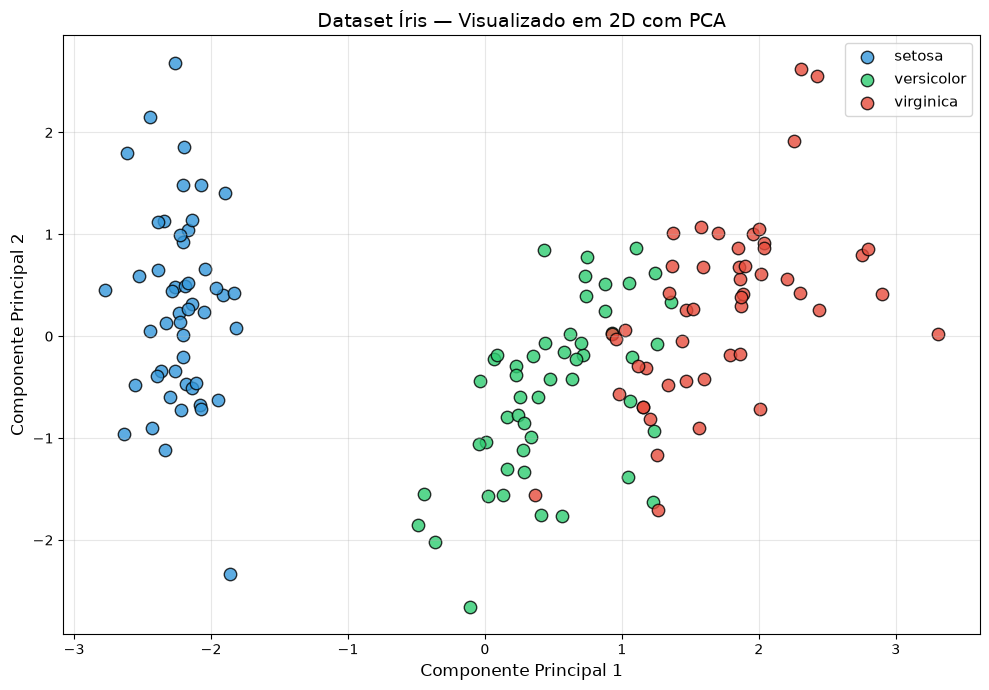

In [7]:
# 🎨 PASSO 3: Visualizar em 2D

plt.figure(figsize=(10, 7))

cores = ['#3498db', '#2ecc71', '#e74c3c']
for i, especie in enumerate(nomes):
    dados = df_pca[df_pca['Espécie'] == especie]
    plt.scatter(dados['Componente 1'], dados['Componente 2'],
                c=cores[i], label=especie, s=80, edgecolors='black', alpha=0.8)

plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.title('Dataset Íris — Visualizado em 2D com PCA', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📊 Variância explicada por cada componente:
  Componente 1: 0.7296 (72.96%)
  Componente 2: 0.2285 (22.85%)
  TOTAL: 0.9581 (95.81%)


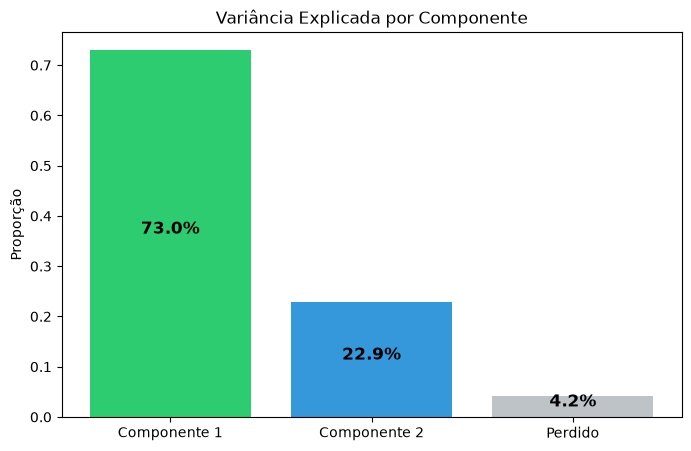

In [8]:
# 📊 PASSO 4: Quanto de informação foi preservada?

variancia = pca.explained_variance_ratio_

print("📊 Variância explicada por cada componente:")
print(f"  Componente 1: {variancia[0]:.4f} ({variancia[0]*100:.2f}%)")
print(f"  Componente 2: {variancia[1]:.4f} ({variancia[1]*100:.2f}%)")
print(f"  TOTAL: {variancia.sum():.4f} ({variancia.sum()*100:.2f}%)")

# Gráfico de barras
plt.figure(figsize=(8, 5))
barras = plt.bar(['Componente 1', 'Componente 2', 'Perdido'],
                  [variancia[0], variancia[1], 1 - variancia.sum()],
                  color=['#2ecc71', '#3498db', '#bdc3c7'])

for bar, val in zip(barras, [variancia[0], variancia[1], 1 - variancia.sum()]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{val*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.title('Variância Explicada por Componente')
plt.ylabel('Proporção')
plt.show()

🔑 Contribuição de cada feature original para os componentes:


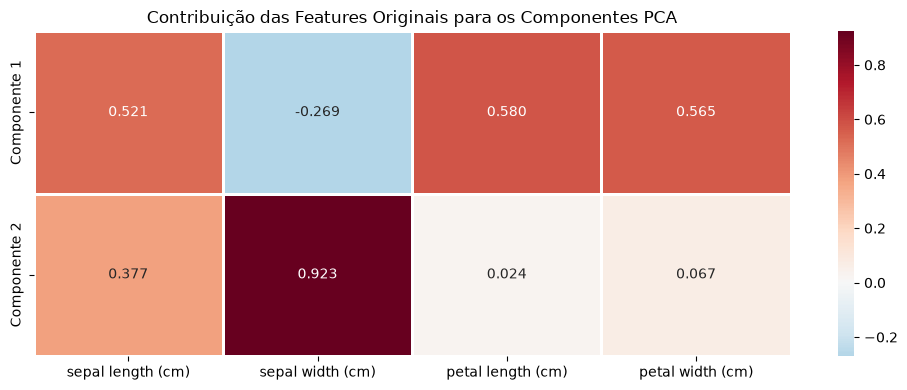

In [9]:
# 🔑 PASSO 5: Quais features originais mais influenciam?

componentes = pd.DataFrame(
    pca.components_,
    columns=iris.feature_names,
    index=['Componente 1', 'Componente 2']
)

print("🔑 Contribuição de cada feature original para os componentes:")
componentes

# Heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(componentes, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', linewidths=1)
plt.title('Contribuição das Features Originais para os Componentes PCA')
plt.tight_layout()
plt.show()

In [17]:
# 🏆 CONCLUSÃO

print(f"""
╔══════════════════════════════════════════╗
║        🔍 PCA — RESULTADO FINAL          ║
╠══════════════════════════════════════════╣
║ Dimensões originais:  4                  ║
║ Dimensões reduzidas:  2                  ║
║ Informação preservada: {variancia.sum()*100:.1f}%             ║
║                                          ║
║ Features mais importantes:               ║
║  - Comprimento da pétala                 ║
║  - Largura da pétala                     ║
║                                          ║
║ Conclusão: Com apenas 2 dimensões,       ║
║ conseguimos visualizar as 3 espécies     ║
║ e preservamos {variancia.sum()*100:.1f}% da informação! 🎉    ║
╚══════════════════════════════════════════╝
""")


╔══════════════════════════════════════════╗
║        🔍 PCA — RESULTADO FINAL          ║
╠══════════════════════════════════════════╣
║ Dimensões originais:  4                  ║
║ Dimensões reduzidas:  2                  ║
║ Informação preservada: 95.8%             ║
║                                          ║
║ Features mais importantes:               ║
║  - Comprimento da pétala                 ║
║  - Largura da pétala                     ║
║                                          ║
║ Conclusão: Com apenas 2 dimensões,       ║
║ conseguimos visualizar as 3 espécies     ║
║ e preservamos 95.8% da informação! 🎉    ║
╚══════════════════════════════════════════╝

